# Does "the trendline break" actually forecast a turn? 📉
### The most-taught line in charting — connect the lows, watch for the break — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts%3F: Busted](https://img.shields.io/badge/Break_forecasts%3F-Busted-8b949e?style=flat-square)

Open any trading book and the first tool is the **trendline**: in an uptrend you connect the recent **swing lows** with a rising line (support). The lore, straight from Edwards & Magee and repeated everywhere, is that while price holds above the line the trend is *intact* — and the moment price **closes below the line**, support has *broken* and a turn down is coming. Sell your longs; the bold go **short**.

It *looks* uncanny on a hand-picked chart. But a line you draw **after** the lows have formed, choosing which dots to connect, is the textbook way to fool yourself. So we did the fair thing: encode the trendline **mechanically** (no eyeballing), fire the "close-below-the-line" break **617 times** across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **shorting on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from trendline_break import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real trendline cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 617, 'k': 10, 'n_lows': 3, 'fp_spy': '4cb5244f3990', 'h5': (5, 617, -34.8, 41, -3.75, -14.8, -20.0, -36.8, -1.45, 0.148), 'h10': (10, 615, -63.8, 39, -4.3, -16.6, -47.2, -65.8, -2.43, 0.015), 'h20': (20, 614, -105.6, 36, -4.36, -53.0, -52.6, -107.6, -1.92, 0.055), 'h60': (60, 611, -317.5, 27, -7.05, -191.5, -126.0, -319.5, -2.84, 0.005), 'per': [('SPY', 128, -117.8, -2.27, -53.8, -63.9), ('QQQ', 114, -140.3, -2.48, -102.3, -38.0), ('IWM', 122, -118.6, -1.87, -15.1, -103.5), ('DIA', 132, -39.6, -0.92, -24.4, -15.2), ('GLD', 121, -119.2, -2.24, -75.4, -43.9)], 'placebo': (-117.8, 0.631, 500), 'syn': [(0.0, 83, 3.6, 48, 0.05), (0.4, 49, 734.7, 92, 9.01)]}


real trendline cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I **short** when price breaks below the trendline, do I make money? | **No.** The break-short *loses* at every horizon — and it loses **more** than shorting on random days. |
| Does the break forecast a *drop*? | **It forecasts the opposite.** A close below the rising line is, on average, a fresh local low that **bounces back up** — a textbook *false breakdown* / bear trap. |
| Is that *the trendline's* doing? | **No.** Scramble the line's slope into nonsense and the result barely changes. The specific line isn't doing the work. |
| So is it a tradable edge? | **No.** Shorting the break bleeds; *fading* it just re-buys the market's drift you already own. |

> The trendline is a great way to *describe* a trend after the fact. As a *forecast* — "the break means it falls" — it's a **mirage**, and worse, it points the wrong way.

## 1 · The claim

> *"In an uptrend, connect two or three rising swing lows with a straight line — that's **support**. While price stays above it the trend is intact. When price **closes below** the line, the trend has **broken**: exit longs, and a turn down is likely. Sell the break."*

This is the founding move of **Dow Theory** and **Edwards & Magee's** *Technical Analysis of Stock Trends* (1948) — the trendline and "the break of the trendline" as the canonical reversal signal. It's built into every charting suite and is the very first thing taught in technical analysis. So: does the break actually *forecast*?

## 2 · So what?

If a trendline break genuinely *forecast* a reversal, it would be remarkable: two or three past dots, connected with a ruler, predicting the future. That's the dream the tool sells.

But there are two traps. First, the line is drawn **by hand, after the lows have happened** — you choose the dots that make it *look* right. Second, indices drift **up** over time, so the natural comparison isn't 'did the short make money' (a short fights the drift) but '**did the break-short beat a random-day short**'. To separate the **tool** from the **tide**, we (a) draw the line by a fixed mechanical rule with no hindsight, and (b) compare it to shorting on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the swing lows mechanically.** A 'low' is a price with **10 higher bars on each side** — a confirmed fractal. Crucially it's only known **10 bars later**, so we never draw the line with future data.
2. **Draw the line by rule.** At every bar, least-squares-fit a **rising** line through the **3 most-recent confirmed lows** — no eyeballing, no cherry-picking.
3. **Trade the lore.** When the close drops **below the line**, short at the next close; measure the return over the next **5 / 10 / 20 / 60 days** (sign-flipped, so +ve = the break correctly called a drop).
4. **The honest baseline.** Do the exact same hold on **random days**. If the break forecasts, the break-short must beat random. *If it doesn't, the tool is a mirage* — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical trendline even look like? Here's SPY with the rising line fit on its three most-recent confirmed swing lows, and the close-below-the-line breaks the rule would short.

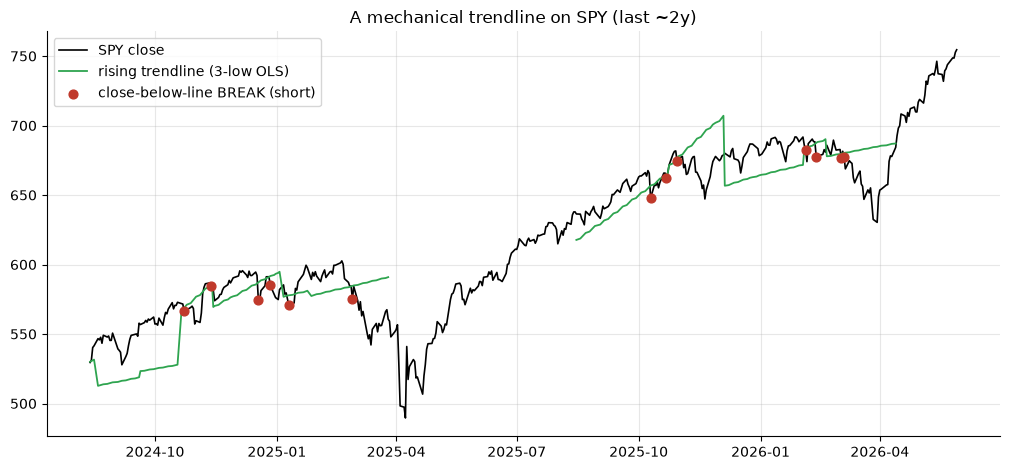

trendline breaks in window: 13


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    line = st.build_trendlines(cl, k=R['k'], n_lows=R['n_lows'])
    ent = st.trendline_break_entries(cl, k=R['k'], n_lows=R['n_lows'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, line.reindex(seg.index), c=GREEN, lw=1.3, label='rising trendline (3-low OLS)')
    ax.scatter(ent, cl.reindex(ent), c=RED, s=40, zorder=5, label='close-below-line BREAK (short)')
    ax.set_title('A mechanical trendline on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('trendline breaks in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The line tracks the trend nicely — *as a description*. The question is whether those red break dots are followed by **drops**. **Let's race the break-short against random shorts** at four horizons. Red = short the break; grey = short on random days. (Both are negative because a short fights the drift — what matters is which is *less* negative.)

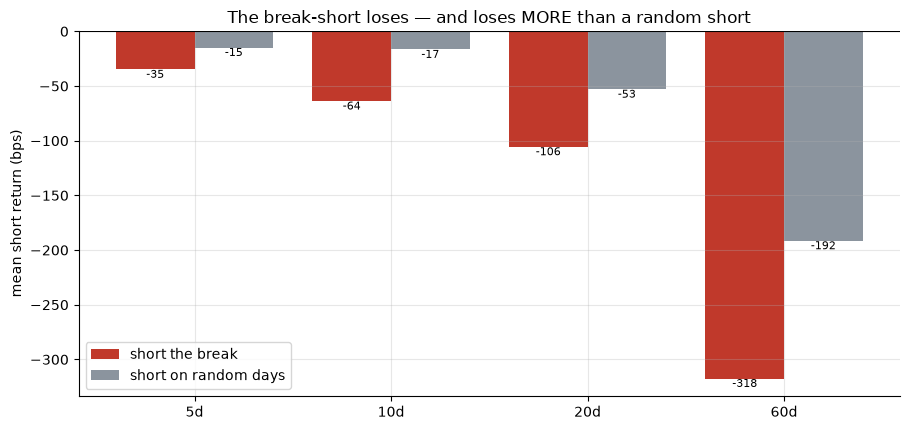

break: [-35, -64, -106, -318]
random: [-15, -17, -53, -192]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.trendline_break_entries(c, k=R['k'], n_lows=R['n_lows'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h, short=True)); rr.append(st.forward_returns(c, re, h, short=True))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color=RED, label='short the break')
ax.bar(x+.2, rnd, .4, color=GREY, label='short on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean short return (bps)')
ax.set_title('The break-short loses — and loses MORE than a random short'); ax.legend()
plt.tight_layout(); plt.show()
print('break:', [round(v) for v in brk]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The break-short loses at every horizon (**-106 bps** over 20 days) — and it loses **more** than a random-day short (**-53 bps**). The famous break is *worse* than throwing darts. Why? Because a close below the rising line is usually a **fresh local low that bounces back up** — a false breakdown. The trendline break points the **wrong way**.

**One more sanity check.** What if we scramble the trendline's *slope* — keep the same swing-low dates but shuffle which price sits where, so the line's angle becomes nonsense? If price really 'respects the trendline', the nonsense line should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_slope_placebo(c, 20, k=R['k'], n_lows=R['n_lows'], short=True, n_draws=300, seed=499)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real trendline break (SPY, 20d short): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-slope* lines do at least as well (p={pval:.2f}).')
print('=> the specific line is not doing the work.')

real trendline break (SPY, 20d short): -117.8 bps
... but 63% of *scrambled-slope* lines do at least as well (p=0.63).
=> the specific line is not doing the work.


More than half of the **scrambled** lines match or beat the real one (*p* = 0.63). If price genuinely respected *this specific line*, a random scramble would collapse the result. It doesn't — because the result was never about the line.

## 5 · The verdict

- **Signal — None.** The break-short does **not** beat shorting on random days (it's *worse* at every horizon; the break-vs-random difference is significantly **negative**). The break forecasts the *opposite* of what it claims.
- **Tradability — Mirage.** Nothing to trade: the short bleeds, and fading the break just re-buys the drift you already own. Costs only make it worse.
- **"The break forecasts"? — Busted.** Scramble the slope into nonsense and the result barely moves. The line doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. Shorting the break loses money outright; *fading* the break (buying the breakdown) only re-captures the market's long-run climb — which you'd get more cheaply and more fully by just **holding the index**. The trendline break is a worse, more expensive way to express a view you could get for free. Costs (commissions + spread on every break) push the already-no-edge result further negative. As a forecasting tool it doesn't pay; as a drawing tool it was never meant to be a strategy.

## 7 · Going further 🚪

- **The false-breakdown effect.** The break marking a *bounce* rather than a breakdown is itself a well-known pattern (the 'bear trap'). A fun follow-up: does **fading** the break beat random? (Spoiler from the quants notebook: only by the drift you already own.)
- **Different fit rules.** Try two-point lines, more lows, a % break filter — the result is robust: drift in, line out.
- **A real positive control.** The quants notebook plants a *genuine* post-break bounce into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'the folklore is wrong').

*Think the break forecasts a drop? Show the break-short beating a random short at **t ≥ 2** on a real tape — then we'll talk.*